# Notebook 01 — Data Cleaning & Exploratory Data Analysis

**Project:** SNAP Participation and Food Access  
**Data:** USDA Food Access Research Atlas (2019)  
**Research question:** Are census tracts with higher SNAP participation more likely to experience low supermarket access, and does this relationship differ between urban and rural areas?

This notebook loads the raw USDA xlsx using `src/clean_food_access.py`, displays key summary statistics, and produces EDA plots saved to `figures/`.

In [37]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from scipy.stats import ttest_ind, probplot
from scipy.stats import f as f_dist
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

FIGURES = Path('..') / 'figures'
FIGURES.mkdir(exist_ok=True)
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data' / 'cleaned'
FIGURES = Path('..') / 'figures'
FIGURES.mkdir(exist_ok=True)

## 1. Load clean data

In [8]:
path = 'food_access_modeling.csv'
df_model = pd.read_csv(path)
df_model.head(5)

,CensusTract,State,County,Urban,urban_label,Pop2010,OHU2010,PovertyRate,MedianFamilyIncome,log_median_family_income,...,log_response,pct_children,pct_seniors,pct_white,pct_black,pct_asian,pct_hispanic,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle
0,1001020100,Alabama,Autauga County,1,Urban,1912,693,11.336453,81250.0,11.305286,...,3.223299,26.516736,11.558577,84.832636,11.349372,0.732218,2.301255,0,0,0
1,1001020200,Alabama,Autauga County,1,Urban,2170,743,17.876788,49000.0,10.799576,...,3.361387,27.926267,9.861751,40.921659,56.082949,0.230415,3.456221,1,1,0
2,1001020300,Alabama,Autauga County,1,Urban,3373,1256,15.046030,62609.0,11.044664,...,2.719919,26.504595,13.015120,76.371183,19.181737,0.504002,2.579306,0,0,0
3,1001020400,Alabama,Autauga County,1,Urban,4386,1722,2.845210,70607.0,11.164885,...,2.177617,23.141815,20.611035,93.160055,4.400365,0.410397,1.937984,0,0,0
4,1001020500,Alabama,Autauga County,1,Urban,10766,4082,15.150891,96334.0,11.475577,...,1.863599,29.370240,10.458852,80.494148,13.347576,2.749396,3.297418,0,0,0


> **Note on dropped rows:** The modeling dataset excludes 30,375 tracts (~42% of raw tracts) that are missing at least one required variable. Most of these are tracts with zero population or zero occupied housing units — they are not meaningfully part of the food access analysis. The full cleaned dataset (72,531 tracts) is preserved in `food_access_cleaned.csv`.

## 2. Key variable summary statistics

In [10]:
summary_cols = [
    'pct_low_income_low_access', 'pct_snap', 'pct_no_vehicle',
    'PovertyRate', 'MedianFamilyIncome', 'log_median_family_income',
    'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian',
]
df_model[summary_cols].describe().round(2)

,pct_low_income_low_access,pct_snap,pct_no_vehicle,PovertyRate,MedianFamilyIncome,log_median_family_income,pct_children,pct_seniors,pct_black,pct_hispanic,pct_asian
count,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00,42156.00
mean,10.57,12.32,6.60,14.10,78699.52,11.17,23.87,14.26,12.55,12.32,3.54
std,13.18,10.84,7.01,11.05,37341.85,0.45,5.95,7.68,20.71,17.56,6.57
min,0.00,0.00,0.00,0.00,2499.00,7.82,0.00,0.00,0.00,0.00,0.00
25%,1.32,4.25,2.15,5.95,53164.75,10.88,20.73,9.57,0.99,2.27,0.46
50%,5.68,9.35,4.48,11.06,70325.00,11.16,23.87,13.52,3.56,5.22,1.37
75%,14.73,17.26,8.57,19.15,96050.75,11.47,27.25,17.41,13.25,13.79,3.67
max,93.46,93.10,85.42,83.48,250001.00,12.43,56.02,89.37,99.34,99.39,81.73


### Urban vs. Rural split

In [11]:
df_model.groupby('urban_label')[['pct_low_income_low_access', 'pct_snap', 'pct_no_vehicle']].describe().round(2)

pct_low_income_low_access                                        \
                                count   mean    std  min   25%   50%    75%   
urban_label                                                                   
Rural                          7336.0   8.41  11.91  0.0  0.49  3.32  11.52   
Urban                         34820.0  11.03  13.39  0.0  1.61  6.19  15.30   

                   pct_snap         ...               pct_no_vehicle        \
               max    count   mean  ...    75%    max          count  mean   
urban_label                         ...                                      
Rural        87.22   7336.0  11.94  ...  15.76  62.79         7336.0  4.55   
Urban        93.46  34820.0  12.40  ...  17.81  93.10        34820.0  7.03   

                                                 
              std  min   25%   50%   75%    max  
urban_label                                      
Rural        4.18  0.0  2.10  3.65  5.87  85.42  
Urban        7.40  0.0  2.17  4.76  9.34  84.82  

[2 rows x 24 columns]

## 3. Missing value summary for modeling variables

In [12]:
check_cols = summary_cols + ['Urban', 'urban_label']
missing = df_model[check_cols].isna().sum().rename('missing')
missing_pct = (missing / len(df_model) * 100).rename('pct_missing').round(2)
pd.concat([missing, missing_pct], axis=1)

,missing,pct_missing
pct_low_income_low_access,0,0.0
pct_snap,0,0.0
pct_no_vehicle,0,0.0
PovertyRate,0,0.0
MedianFamilyIncome,0,0.0
log_median_family_income,0,0.0
pct_children,0,0.0
pct_seniors,0,0.0
pct_black,0,0.0
pct_hispanic,0,0.0


## 4. Correlation table (numeric modeling variables)

In [13]:
corr_cols = [
    'pct_low_income_low_access', 'pct_snap', 'pct_no_vehicle',
    'PovertyRate', 'log_median_family_income',
    'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian',
    'Urban',
]
df_model[corr_cols].corr().round(3)

,pct_low_income_low_access,pct_snap,pct_no_vehicle,PovertyRate,log_median_family_income,pct_children,pct_seniors,pct_black,pct_hispanic,pct_asian,Urban
pct_low_income_low_access,1.000,0.350,0.206,0.376,-0.387,0.110,-0.059,0.246,0.069,-0.152,0.075
pct_snap,0.350,1.000,0.668,0.797,-0.783,0.253,-0.160,0.503,0.240,-0.221,0.016
pct_no_vehicle,0.206,0.668,1.000,0.624,-0.521,-0.017,-0.006,0.464,0.044,-0.098,0.134
PovertyRate,0.376,0.797,0.624,1.000,-0.802,0.098,-0.146,0.464,0.212,-0.197,-0.033
log_median_family_income,-0.387,-0.783,-0.521,-0.802,1.000,-0.107,0.051,-0.426,-0.217,0.344,0.160
pct_children,0.110,0.253,-0.017,0.098,-0.107,1.000,-0.593,0.149,0.337,0.020,0.058
pct_seniors,-0.059,-0.160,-0.006,-0.146,0.051,-0.593,1.000,-0.174,-0.259,-0.150,-0.125
pct_black,0.246,0.503,0.464,0.464,-0.426,0.149,-0.174,1.000,-0.072,-0.091,0.127
pct_hispanic,0.069,0.240,0.044,0.212,-0.217,0.337,-0.259,-0.072,1.000,0.051,0.142
pct_asian,-0.152,-0.221,-0.098,-0.197,0.344,0.020,-0.150,-0.091,0.051,1.000,0.213


## 5. EDA Plots

All figures are saved to `figures/`.

### Fig 1 — Distribution of the response variable

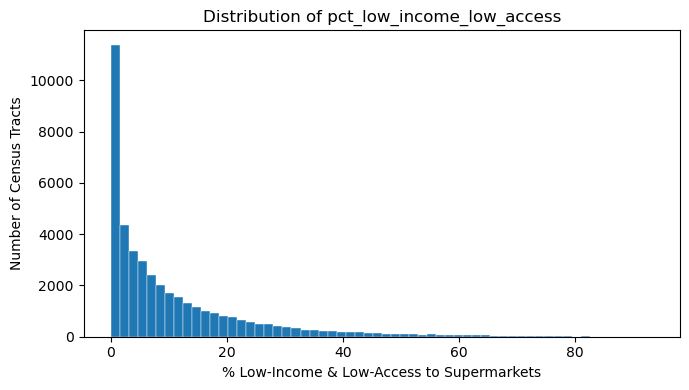

Saved: figures/01_hist_response.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_model['pct_low_income_low_access'].dropna(), bins=60, edgecolor='white', linewidth=0.3)
ax.set_xlabel('% Low-Income & Low-Access to Supermarkets')
ax.set_ylabel('Number of Census Tracts')
ax.set_title('Distribution of pct_low_income_low_access')
plt.tight_layout()
fig.savefig(FIGURES / '01_hist_response.png', dpi=150)
plt.show()
print('Saved: figures/01_hist_response.png')

**Interpretation:** The response variable is strongly right-skewed. Most census tracts have a relatively small share of low-income, low-access residents, but a long upper tail of high-need tracts exists. This suggests a log transformation (`log_response`) may be worth considering for regression.

### Fig 2 — Distribution of the main explanatory variable

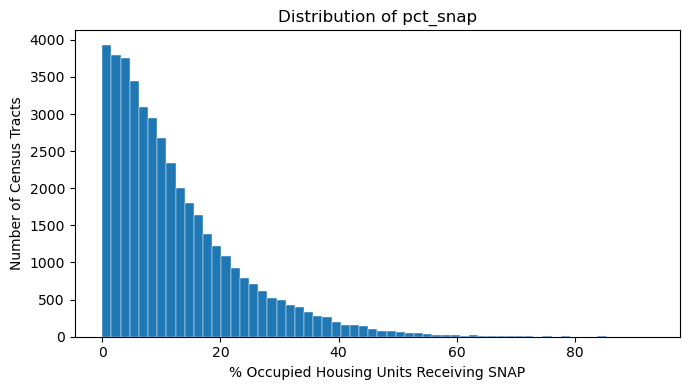

Saved: figures/02_hist_pct_snap.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_model['pct_snap'].dropna(), bins=60, edgecolor='white', linewidth=0.3)
ax.set_xlabel('% Occupied Housing Units Receiving SNAP')
ax.set_ylabel('Number of Census Tracts')
ax.set_title('Distribution of pct_snap')
plt.tight_layout()
fig.savefig(FIGURES / '02_hist_pct_snap.png', dpi=150)
plt.show()
print('Saved: figures/02_hist_pct_snap.png')

**Interpretation:** SNAP participation is also right-skewed. The majority of tracts have under 20% SNAP uptake, but a meaningful number of tracts — likely high-poverty urban and rural areas — have substantially higher rates.

### Fig 3 — Scatterplot: SNAP participation vs. low-income low-access

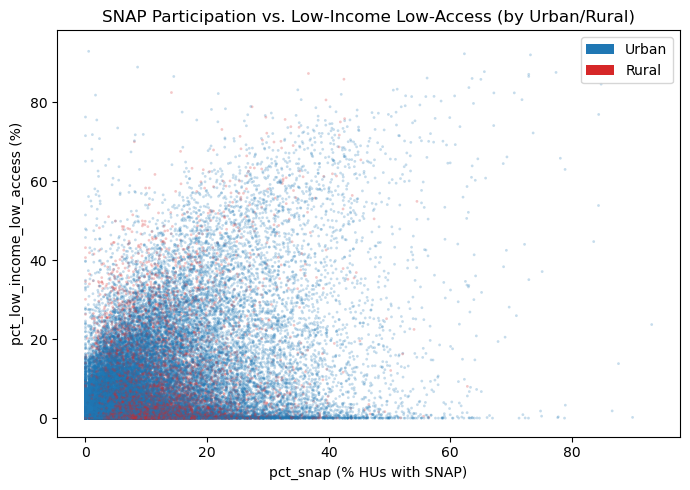

Saved: figures/03_scatter_snap_vs_lila.png


In [16]:
colors = df_model['Urban'].map({1: '#1f77b4', 0: '#d62728'})
legend_elements = [
    Patch(facecolor='#1f77b4', label='Urban'),
    Patch(facecolor='#d62728', label='Rural'),
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_model['pct_snap'], df_model['pct_low_income_low_access'],
    c=colors, alpha=0.25, s=4, linewidths=0
)
ax.legend(handles=legend_elements)
ax.set_xlabel('pct_snap (% HUs with SNAP)')
ax.set_ylabel('pct_low_income_low_access (%)')
ax.set_title('SNAP Participation vs. Low-Income Low-Access (by Urban/Rural)')
plt.tight_layout()
fig.savefig(FIGURES / '03_scatter_snap_vs_lila.png', dpi=150)
plt.show()
print('Saved: figures/03_scatter_snap_vs_lila.png')

**Interpretation:** There is a positive association between SNAP participation and low-income low-access rates. Urban tracts (blue) tend to cluster at lower low-access values despite high SNAP rates, while rural tracts (red) show more spread at higher low-access values — suggesting the SNAP–access relationship may differ by urban/rural status, which directly motivates our interaction model.

### Fig 4 — Boxplot of response by urban/rural

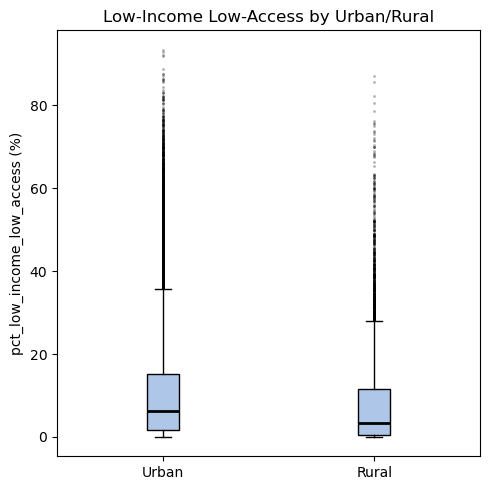

Saved: figures/04_boxplot_lila_by_urban.png


In [17]:
urban_vals = df_model.loc[df_model['Urban'] == 1, 'pct_low_income_low_access'].dropna()
rural_vals = df_model.loc[df_model['Urban'] == 0, 'pct_low_income_low_access'].dropna()

fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(
    [urban_vals, rural_vals], labels=['Urban', 'Rural'], patch_artist=True,
    boxprops=dict(facecolor='#aec7e8'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
ax.set_ylabel('pct_low_income_low_access (%)')
ax.set_title('Low-Income Low-Access by Urban/Rural')
plt.tight_layout()
fig.savefig(FIGURES / '04_boxplot_lila_by_urban.png', dpi=150)
plt.show()
print('Saved: figures/04_boxplot_lila_by_urban.png')

**Interpretation:** Rural tracts have a notably higher median and wider spread of `pct_low_income_low_access` compared to urban tracts. This confirms that including `Urban` as a covariate (and interaction term) in regression is important.

### Fig 5 — Scatterplot: No-vehicle households vs. low-income low-access

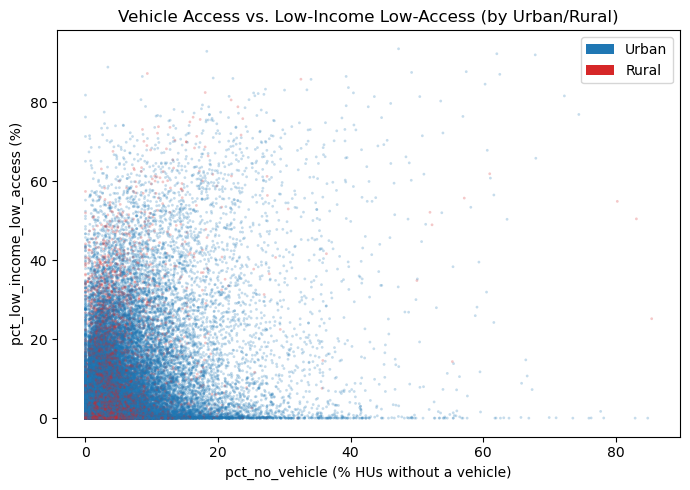

Saved: figures/05_scatter_noveh_vs_lila.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_model['pct_no_vehicle'], df_model['pct_low_income_low_access'],
    c=colors, alpha=0.25, s=4, linewidths=0
)
ax.legend(handles=legend_elements)
ax.set_xlabel('pct_no_vehicle (% HUs without a vehicle)')
ax.set_ylabel('pct_low_income_low_access (%)')
ax.set_title('Vehicle Access vs. Low-Income Low-Access (by Urban/Rural)')
plt.tight_layout()
fig.savefig(FIGURES / '05_scatter_noveh_vs_lila.png', dpi=150)
plt.show()
print('Saved: figures/05_scatter_noveh_vs_lila.png')

**Interpretation:** Vehicle access shows a moderate positive association with low-income low-access rates in rural tracts. In urban tracts the pattern is weaker, consistent with urban areas having more public transit alternatives. This motivates the `pct_no_vehicle:Urban` interaction term.

## 6. Output file locations

| File | Description |
|---|---|
| `data/cleaned/food_access_cleaned.csv` | Full cleaned dataset (72,531 tracts, 159 columns) |
| `data/cleaned/food_access_modeling.csv` | Regression-ready subset (42,156 tracts, 26 columns) |
| `data/cleaned/data_dictionary_cleaned.csv` | Variable lookup from USDA |
| `report/data_cleaning_summary.md` | Cleaning log and regression notes |
| `figures/` | EDA plots |

See `report/data_cleaning_summary.md` for the suggested regression models and notes on handling spatial clustering.

# Extended EDA & Regression Modeling

**Project:** SNAP Participation and Food Access  
**Data:** USDA Food Access Research Atlas (2019)  
**Research question:** Are census tracts with higher SNAP participation more likely to experience low supermarket access, and does this relationship differ between urban and rural areas?

---
## 2. Extended EDA

### Fig 6 — Correlation Heatmap

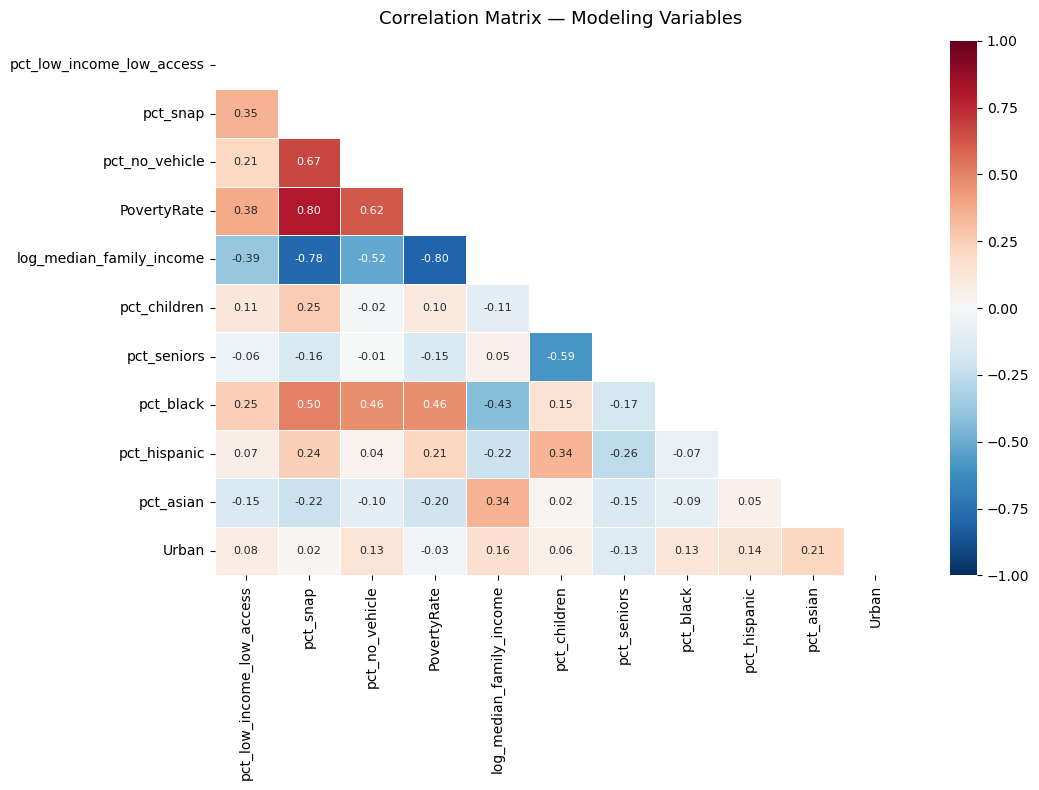

In [19]:
corr_cols = [
    'pct_low_income_low_access', 'pct_snap', 'pct_no_vehicle',
    'PovertyRate', 'log_median_family_income',
    'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian',
    'Urban',
]
corr = df_model[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Modeling Variables', fontsize=13, pad=12)
plt.tight_layout()
fig.savefig(FIGURES / '06_correlation_heatmap.png', dpi=150)
plt.show()

`PovertyRate` and `log_median_family_income` correlate at −0.81, which is strong enough to cause multicollinearity if both are included. Models A and C use income, and Model B uses poverty rate as a robustness check.

### Fig 7 — Urban vs Rural Distributions

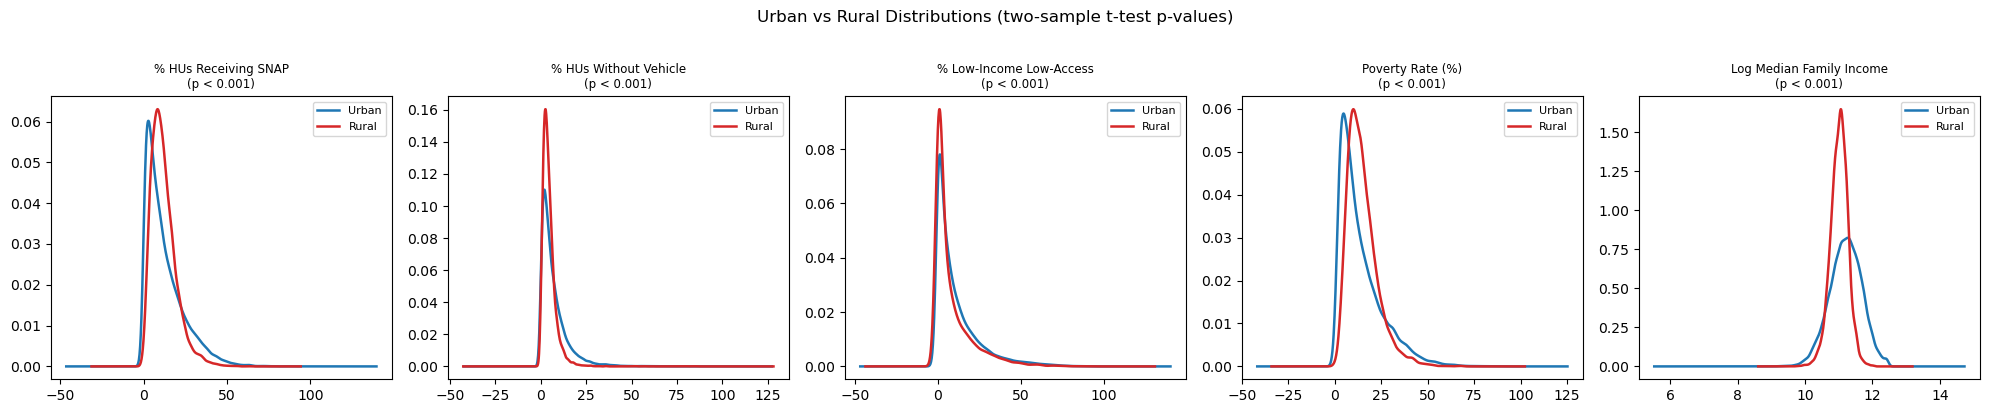

In [21]:
key_vars = {
    'pct_snap': '% HUs Receiving SNAP',
    'pct_no_vehicle': '% HUs Without Vehicle',
    'pct_low_income_low_access': '% Low-Income Low-Access',
    'PovertyRate': 'Poverty Rate (%)',
    'log_median_family_income': 'Log Median Family Income',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
palette = {'Urban': '#1f77b4', 'Rural': '#d62728'}

for ax, (col, label) in zip(axes, key_vars.items()):
    for group, color in palette.items():
        subset = df_model.loc[df_model['urban_label'] == group, col].dropna()
        subset.plot.kde(ax=ax, label=group, color=color, linewidth=1.8)
    u_vals = df_model.loc[df_model['urban_label'] == 'Urban', col].dropna()
    r_vals = df_model.loc[df_model['urban_label'] == 'Rural', col].dropna()
    _, p = ttest_ind(u_vals, r_vals, equal_var=False)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{label}\n({p_str})', fontsize=8.5)
    ax.set_ylabel('')
    ax.legend(fontsize=8)

plt.suptitle('Urban vs Rural Distributions (two-sample t-test p-values)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / '07_urban_rural_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

All five variables differ significantly between urban and rural tracts (all p < 0.001), justifying `Urban` as a predictor and motivating the interaction model.

### Fig 8 — Log Transformation Justification

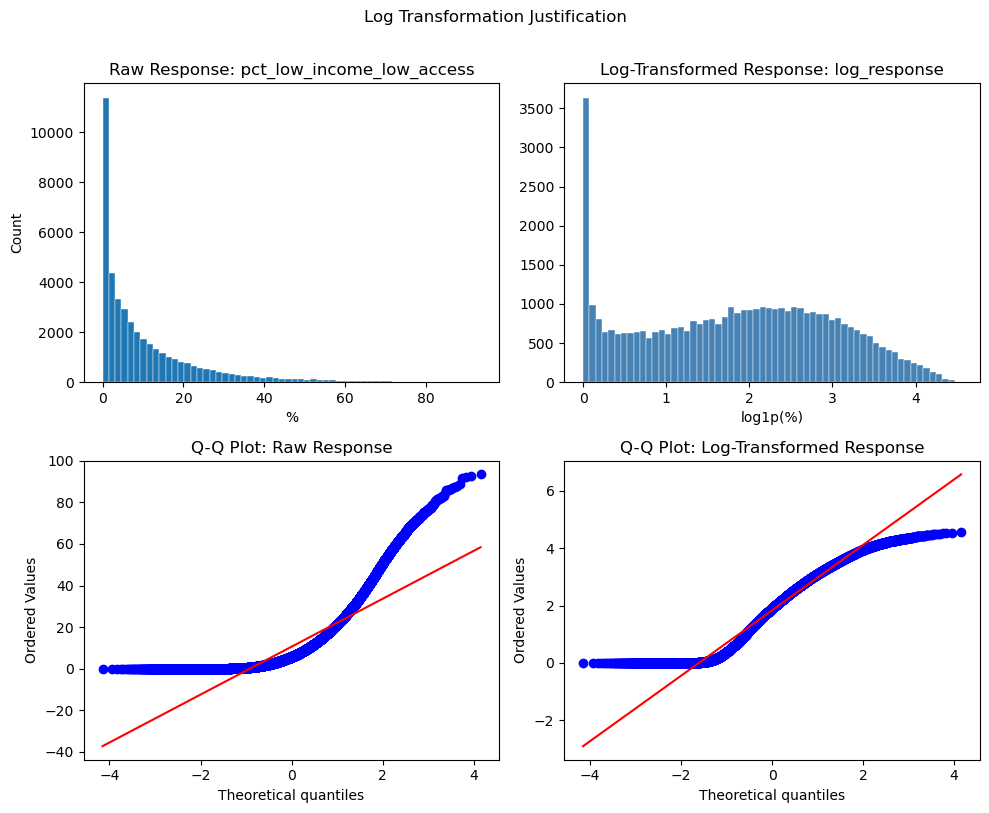

Raw skewness:             2.043
Log-transformed skewness: -0.002


In [22]:
raw  = df_model['pct_low_income_low_access'].dropna()
logv = df_model['log_response'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(raw, bins=60, edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Raw Response: pct_low_income_low_access')
axes[0, 0].set_xlabel('%')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(logv, bins=60, edgecolor='white', linewidth=0.3, color='steelblue')
axes[0, 1].set_title('Log-Transformed Response: log_response')
axes[0, 1].set_xlabel('log1p(%)')

probplot(raw, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Raw Response')

probplot(logv, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log-Transformed Response')

plt.suptitle('Log Transformation Justification', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / '08_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Raw skewness:             {raw.skew():.3f}')
print(f'Log-transformed skewness: {logv.skew():.3f}')

The raw response is heavily right-skewed, log1p brings it much closer to symmetric (see skewness values above). All regression models use `log_response` as the dependent variable.

### Fig 9 — SNAP vs Low-Access by Income Quartile

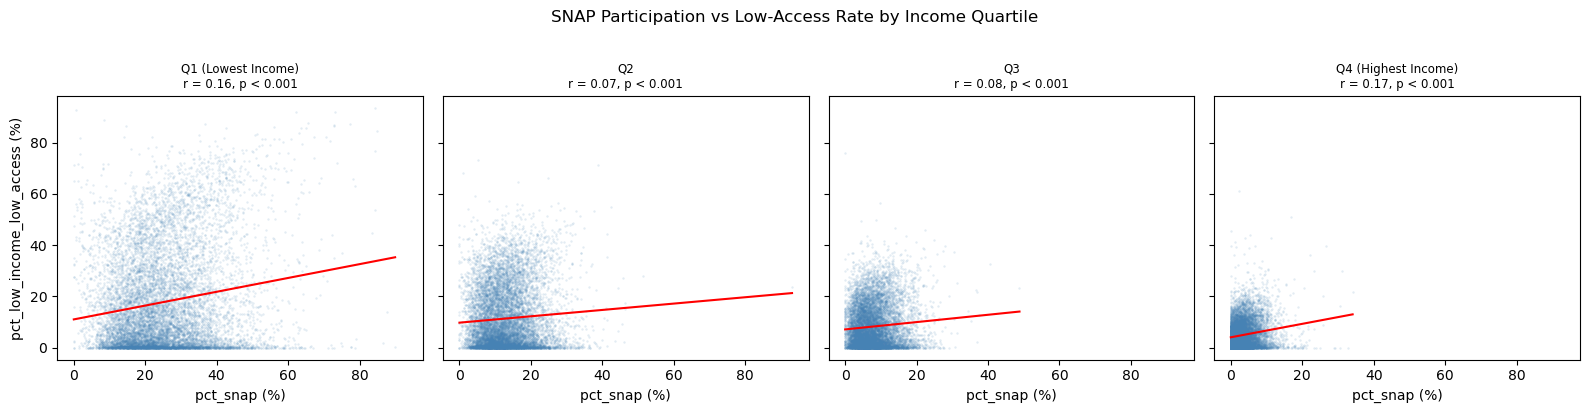

In [23]:
df_model['income_quartile'] = pd.qcut(
    df_model['MedianFamilyIncome'], q=4,
    labels=['Q1 (Lowest Income)', 'Q2', 'Q3', 'Q4 (Highest Income)']
)

quartiles = ['Q1 (Lowest Income)', 'Q2', 'Q3', 'Q4 (Highest Income)']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)

for ax, q in zip(axes, quartiles):
    sub = df_model[df_model['income_quartile'] == q].dropna(
        subset=['pct_snap', 'pct_low_income_low_access']
    )
    ax.scatter(sub['pct_snap'], sub['pct_low_income_low_access'],
               alpha=0.15, s=3, linewidths=0, color='steelblue')
    x, y = sub['pct_snap'].values, sub['pct_low_income_low_access'].values
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{q}\nr = {r:.2f}, {p_str}', fontsize=8.5)
    ax.set_xlabel('pct_snap (%)')

axes[0].set_ylabel('pct_low_income_low_access (%)')
plt.suptitle('SNAP Participation vs Low-Access Rate by Income Quartile', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / '09_snap_lila_by_income_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

The positive SNAP–LILA association holds across all income quartiles, showing it is not simply from income confounding.

### Fig 10 — Low-Access Rate by Racial Majority of Tract

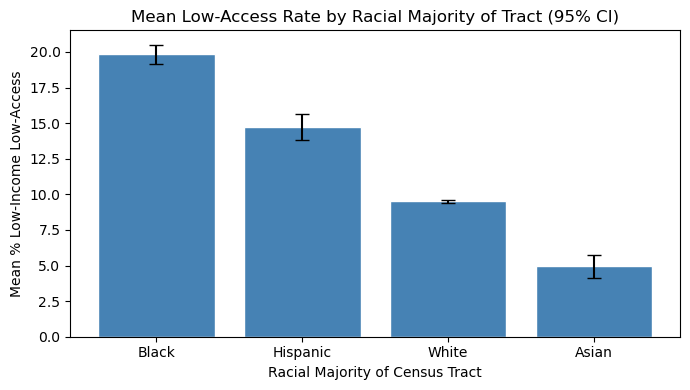

racial_majority  count      mean
          Black   3605 19.826633
       Hispanic   1740 14.717364
          White  36489  9.512424
          Asian    322  4.932153


In [24]:
racial_cols = ['pct_white', 'pct_black', 'pct_hispanic', 'pct_asian']
df_model['racial_majority'] = (
    df_model[racial_cols].idxmax(axis=1)
    .str.replace('pct_', '').str.title()
)

demo = (
    df_model.groupby('racial_majority')['pct_low_income_low_access']
    .agg(['mean', 'count', 'sem'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    demo['racial_majority'], demo['mean'],
    yerr=1.96 * demo['sem'],
    capsize=5, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Racial Majority of Census Tract')
ax.set_ylabel('Mean % Low-Income Low-Access')
ax.set_title('Mean Low-Access Rate by Racial Majority of Tract (95% CI)')
plt.tight_layout()
fig.savefig(FIGURES / '10_demographics_lila.png', dpi=150)
plt.show()

print(demo[['racial_majority', 'count', 'mean']].to_string(index=False))

Tracts with Black or Hispanic majorities have higher mean LILA rates. Racial composition is included as a control variable in all regression models.

---
## 3. Regression Modeling

**Response:** `log_response` (log1p of `pct_low_income_low_access`), justified above.

**Excluded variables:** `LILATracts_*` (derived from the response), `LowIncomeTracts` (redundant with `PovertyRate`), `TractSNAP`/`TractHUNV` (raw counts, use % versions), `pct_white` (reference category for racial composition).

**Multicollinearity:** `PovertyRate` and `log_median_family_income` correlate at −0.81, so they are never included together. Model A uses income, Model B uses poverty rate.

**Standard errors:** Clustered at State level to handle within-state spatial autocorrelation.

### Model A — Main Effects (income as socioeconomic control)

In [25]:
formula_A = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_A = smf.ols(formula_A, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_A.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     169.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.66e-34
Time:                        21:29:09   Log-Likelihood:                -63180.
No. Observations:               42156   AIC:                         1.264e+05
Df Residuals:                   42146   BIC:                         1.265e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Model B — Main Effects (poverty rate as socioeconomic control)

Replaces `log_median_family_income` with `PovertyRate` as a robustness check. In Model B, `pct_snap` becomes significant, reflecting that income absorbs much of the SNAP signal in Model A (SNAP eligibility is income-based, so the two are highly correlated).

In [26]:
formula_B = (
    'log_response ~ pct_snap + PovertyRate'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_B = smf.ols(formula_B, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_B.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     163.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           6.95e-34
Time:                        21:29:24   Log-Likelihood:                -63552.
No. Observations:               42156   AIC:                         1.271e+05
Df Residuals:                   42146   BIC:                         1.272e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5804      0.078      7.

### Model C — Interaction Model

Adds `pct_snap:Urban` and `pct_no_vehicle:Urban`. The `pct_snap:Urban` coefficient directly tests whether the SNAP–LILA association differs between urban and rural tracts.

In [27]:
formula_C = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_snap:Urban + pct_no_vehicle:Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_C = smf.ols(formula_C, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_C.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     224.7
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.47e-38
Time:                        21:29:44   Log-Likelihood:                -63107.
No. Observations:               42156   AIC:                         1.262e+05
Df Residuals:                   42144   BIC:                         1.263e+05
Df Model:                          11                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Variance Inflation Factors

Checked on the Model A predictors.

In [28]:
X_vif = df_model[[
    'pct_snap', 'log_median_family_income', 'pct_no_vehicle',
    'Urban', 'pct_children', 'pct_seniors',
    'pct_black', 'pct_hispanic', 'pct_asian'
]].dropna().copy()
X_vif['const'] = 1.0

vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df[vif_df['Variable'] != 'const'].to_string(index=False))

                Variable      VIF
                pct_snap 4.039573
log_median_family_income 3.172986
          pct_no_vehicle 2.101404
            pct_children 1.791413
             pct_seniors 1.636105
               pct_black 1.577212
            pct_hispanic 1.350655
               pct_asian 1.220336
                   Urban 1.218577


### Model Comparison

In [29]:
comparison = summary_col(
    [model_A, model_B, model_C],
    model_names=['Model A\n(income)', 'Model B\n(poverty)', 'Model C\n(interactions)'],
    stars=True,
    float_format='%.4f',
    info_dict={
        'AIC': lambda x: f'{x.aic:.1f}',
        'Observations': lambda x: f'{int(x.nobs):,}',
    }
)
print(comparison)


                          Model A    Model B      Model C    
                          (income)  (poverty)  (interactions)
-------------------------------------------------------------
Intercept                10.7487*** 0.5804***  10.6798***    
                         (0.4020)   (0.0781)   (0.3905)      
pct_snap                 0.0026     0.0099***  -0.0146**     
                         (0.0018)   (0.0021)   (0.0058)      
log_median_family_income -0.8707***            -0.8588***    
                         (0.0364)              (0.0355)      
pct_no_vehicle           -0.0269*** -0.0326*** 0.0129        
                         (0.0027)   (0.0030)   (0.0117)      
Urban                    0.6698***  0.5655***  0.6349***     
                         (0.0630)   (0.0637)   (0.0877)      
pct_children             0.0169***  0.0182***  0.0153***     
                         (0.0023)   (0.0025)   (0.0023)      
pct_seniors              0.0079***  0.0127***  0.0079***     
       

#### F-test: do the interaction terms in Model C jointly improve fit over Model A?

$H_0$: pct_snap:Urban = 0 and pct_no_vehicle:Urban = 0

In [30]:
r2_A = model_A.rsquared
r2_C = model_C.rsquared
n = int(model_C.nobs)
q = 2
k = int(model_C.df_model)

f_stat = ((r2_C - r2_A) / q) / ((1 - r2_C) / (n - k - 1))
p_val = 1 - f_dist.cdf(f_stat, q, n - k - 1)

print('F-test: Model A vs Model C')
print('H0: interaction terms are jointly zero')
print(f'F({q}, {n - k - 1}) = {f_stat:.3f}')
print(f'p-value = {p_val:.2e}')

F-test: Model A vs Model C
H0: interaction terms are jointly zero
F(2, 42144) = 73.520
p-value = 1.11e-16


### Fig 11 — Model C Coefficient Plot

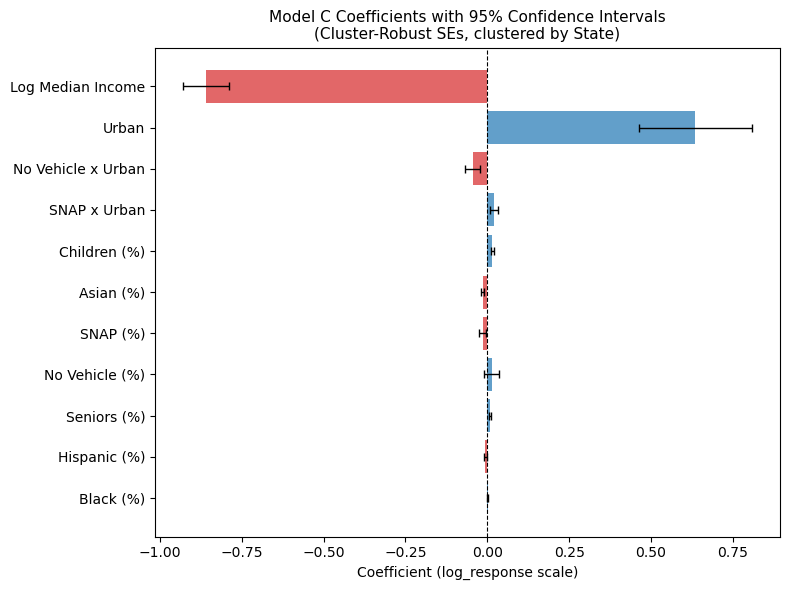

In [31]:
rename = {
    'pct_snap': 'SNAP (%)',
    'log_median_family_income': 'Log Median Income',
    'pct_no_vehicle': 'No Vehicle (%)',
    'Urban': 'Urban',
    'pct_children': 'Children (%)',
    'pct_seniors': 'Seniors (%)',
    'pct_black': 'Black (%)',
    'pct_hispanic': 'Hispanic (%)',
    'pct_asian': 'Asian (%)',
    'pct_snap:Urban': 'SNAP x Urban',
    'Urban:pct_snap': 'SNAP x Urban',
    'pct_no_vehicle:Urban': 'No Vehicle x Urban',
    'Urban:pct_no_vehicle': 'No Vehicle x Urban',
}

coef = model_C.params.drop('Intercept')
ci = model_C.conf_int().drop('Intercept')
coef.index = [rename.get(i, i) for i in coef.index]
ci.index = coef.index

order = coef.abs().sort_values().index
coef, ci = coef[order], ci.loc[order]

pt_colors = ['#d62728' if v < 0 else '#1f77b4' for v in coef]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(coef)), coef.values, color=pt_colors, alpha=0.7)
ax.errorbar(
    coef.values, range(len(coef)),
    xerr=[(coef.values - ci[0].values), (ci[1].values - coef.values)],
    fmt='none', color='black', capsize=3, linewidth=1
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(coef)))
ax.set_yticklabels(coef.index, fontsize=10)
ax.set_xlabel('Coefficient (log_response scale)')
ax.set_title(
    'Model C Coefficients with 95% Confidence Intervals\n'
    '(Cluster-Robust SEs, clustered by State)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES / '11_coefficient_plot.png', dpi=150)
plt.show()

# Regression Diagnostic

**Project:** SNAP Participation and Food Access  
**Data:** USDA Food Access Research Atlas (2019)  
**Research question:** Are census tracts with higher SNAP participation more likely to experience low supermarket access, and does this relationship differ between urban and rural areas?

# Diagnostics

The data and the first 5 rows of the data.
The 5 different things we need to check:
* Independence: $\epsilon_1 ... \epsilon_n$ are independent
* Identical / homoscedasticity: The errors have constant variance, i.e., $\epsilon_1 ... \epsilon_n$ are $N(0,r^2)$
* Normally distributed (Normality): $\epsilon_1 ... \epsilon_n$ are $\underset{=}{N}(0,r^2)$
* Linearity: The relationship between the independent variables and the response is linear $y_i = B_0 + B_1 x_i$
* Multicollinearity: The Case where two or more covariates are highly correlated. 

In [33]:
path = 'food_access_modeling.csv'
df_model = pd.read_csv(path)
df_model.head(5)

,CensusTract,State,County,Urban,urban_label,Pop2010,OHU2010,PovertyRate,MedianFamilyIncome,log_median_family_income,...,log_response,pct_children,pct_seniors,pct_white,pct_black,pct_asian,pct_hispanic,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle
0,1001020100,Alabama,Autauga County,1,Urban,1912,693,11.336453,81250.0,11.305286,...,3.223299,26.516736,11.558577,84.832636,11.349372,0.732218,2.301255,0,0,0
1,1001020200,Alabama,Autauga County,1,Urban,2170,743,17.876788,49000.0,10.799576,...,3.361387,27.926267,9.861751,40.921659,56.082949,0.230415,3.456221,1,1,0
2,1001020300,Alabama,Autauga County,1,Urban,3373,1256,15.046030,62609.0,11.044664,...,2.719919,26.504595,13.015120,76.371183,19.181737,0.504002,2.579306,0,0,0
3,1001020400,Alabama,Autauga County,1,Urban,4386,1722,2.845210,70607.0,11.164885,...,2.177617,23.141815,20.611035,93.160055,4.400365,0.410397,1.937984,0,0,0
4,1001020500,Alabama,Autauga County,1,Urban,10766,4082,15.150891,96334.0,11.475577,...,1.863599,29.370240,10.458852,80.494148,13.347576,2.749396,3.297418,0,0,0


---
### Fitting the model to a full model

In [34]:
response = 'pct_low_income_low_access'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_model).fit()

full_model.summary()

full_formula:  pct_low_income_low_access ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     pct_low_income_low_access   R-squared:                       0.195
Model:                                   OLS   Adj. R-squared:                  0.195
Method:                        Least Squares   F-statistic:                     1022.
Date:                       Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                               21:32:06   Log-Likelihood:            -1.6394e+05
No. Observations:                      42156   AIC:                         3.279e+05
Df Residuals:                          42145   BIC:                         3.280e+05
Df Model:                                 10                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   80.5962      2.954     27.287      0.000      74.807      86.385
pct_snap                     0.0279      0.011      2.486      0.013       0.006       0.050
PovertyRate                  0.2540      0.010     24.435      0.000       0.234       0.274
log_median_family_income    -7.3335      0.254    -28.852      0.000      -7.832      -6.835
pct_no_vehicle              -0.2196      0.012    -18.094      0.000      -0.243      -0.196
Urban                        5.2818      0.168     31.496      0.000       4.953       5.610
pct_children                 0.1925      0.013     14.610      0.000       0.167       0.218
pct_seniors                  0.0727      0.010      7.452      0.000       0.054       0.092
pct_black                    0.0308      0.003      8.794      0.000       0.024       0.038
pct_hispanic                -0.0493      0.004    -12.900      0.000      -0.057      -0.042
pct_asian                   -0.0982      0.010    -10.125      0.000      -0.117      -0.079
==============================================================================
Omnibus:                     9774.425   Durbin-Watson:                   1.636
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24609.872
Skew:                           1.272   Prob(JB):                         0.00
Kurtosis:                       5.746   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Identical/homoscedasticity and Linearity

We check whether the error have constant variance for homoscedasticity. Additionally, we check if the residuals are randomly scattered around 0 then the assumption of linearity is satisfied.

Analysis: Both conditions are not reached as we can see linearity isn't true as it centers at a different value.

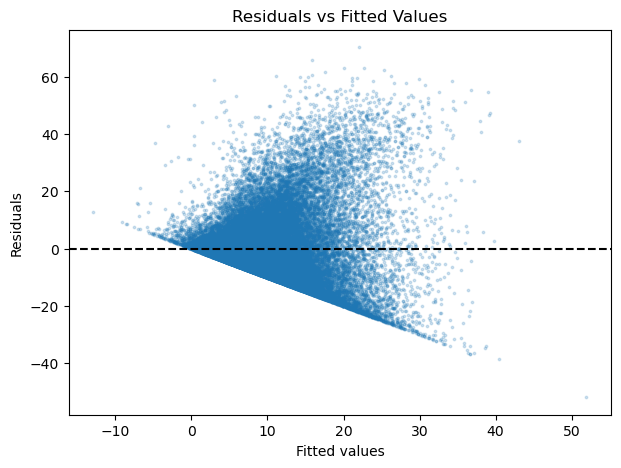

In [35]:
plt.figure(figsize=(7, 5))
plt.scatter(full_model.fittedvalues, full_model.resid, s=3, alpha=0.2)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

### Normally distributed

We check whether the model residuals look normal. 

Analysis: We can see that the plot is right skewed and the tail shift away from our expected linear condition. Thus, we don't reach the normality condition.

<Figure size 700x500 with 0 Axes>

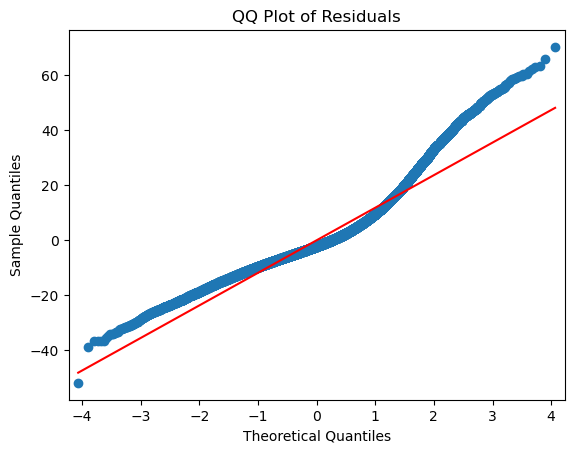

In [38]:
plt.figure(figsize=(7, 5))
sm.qqplot(full_model.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Multicollinearity

We can see that the covariates are nearly highly correlated. This is the case with pct_snap and pct_no_vehicles. Alongside pct_black with pct_snap, pct_no_vehicle,and poverty rate. The VIF aren't >5 but VIF for pct_snap is 4.477 so multicollinearity is still a risk.

['pct_snap', 'PovertyRate', 'log_median_family_income', 'pct_no_vehicle', 'Urban', 'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian']
VIF: pct_snap:  4.477
VIF: PovertyRate:  3.980
VIF: log_median_family_income:  4.015
VIF: pct_no_vehicle:  2.185
VIF: Urban:  1.219
VIF: pct_children:  1.852
VIF: pct_seniors:  1.694
VIF: pct_black:  1.583
VIF: pct_hispanic:  1.357
VIF: pct_asian:  1.226


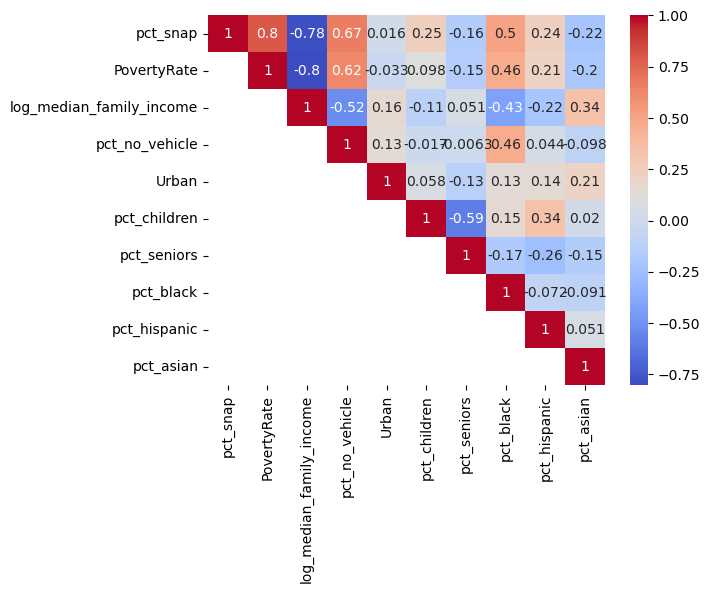

In [39]:
covariates_term = ['pct_snap','PovertyRate','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
print(covariates_term)
corr_table = df_model[covariates_term].corr() 
sns.heatmap(corr_table, annot=True, cmap='coolwarm', mask=np.tril(corr_table, k=-1))

exog = full_model.model.exog
names = full_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

---

### All 3 new models A,B,and C

Thus, we should changed our model such that model doesn't have issues with homoscedasticity, normality, linearity,and multicollinearity.

In [40]:
formula_A = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_A = smf.ols(formula_A, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_A.summary())

formula_B = (
    'log_response ~ pct_snap + PovertyRate'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_B = smf.ols(formula_B, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_B.summary())

formula_C = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_snap:Urban + pct_no_vehicle:Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_C = smf.ols(formula_C, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_C.summary())
print('Model A VIF')
exog = model_A.model.exog
names = model_A.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')
print('Model B VIF')
exog = model_B.model.exog
names = model_B.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')
print('Model C VIF')
exog = model_C.model.exog
names = model_C.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

Model A VIF
VIF: pct_snap:  4.040
VIF: log_median_family_income:  3.173
VIF: pct_no_vehicle:  2.101
VIF: Urban:  1.219
VIF: pct_children:  1.791
VIF: pct_seniors:  1.636
VIF: pct_black:  1.577
VIF: pct_hispanic:  1.351
VIF: pct_asian:  1.220
Model B VIF
VIF: pct_snap:  3.858
VIF: PovertyRate:  3.145
VIF: pct_no_vehicle:  2.172
VIF: Urban:  1.155
VIF: pct_children:  1.847
VIF: pct_seniors:  1.681
VIF: pct_black:  1.565
VIF: pct_hispanic:  1.329
VIF: pct_asian:  1.152
Model C VIF
VIF: pct_snap:  18.251
VIF: log_median_family_income:  3.195
VIF: pct_no_vehicle:  23.227
VIF: Urban:  3.661
VIF: pct_snap:Urban:  21.757
VIF: pct_no_vehicle:Urban:  27.180
VIF: pct_children:  1.812
VIF: pct_seniors:  1.636
VIF: pct_black:  1.580
VIF: pct_hispanic:  1.354
VIF: pct_asian:  1.224


#### Checking all conditions for model A diagnosis 

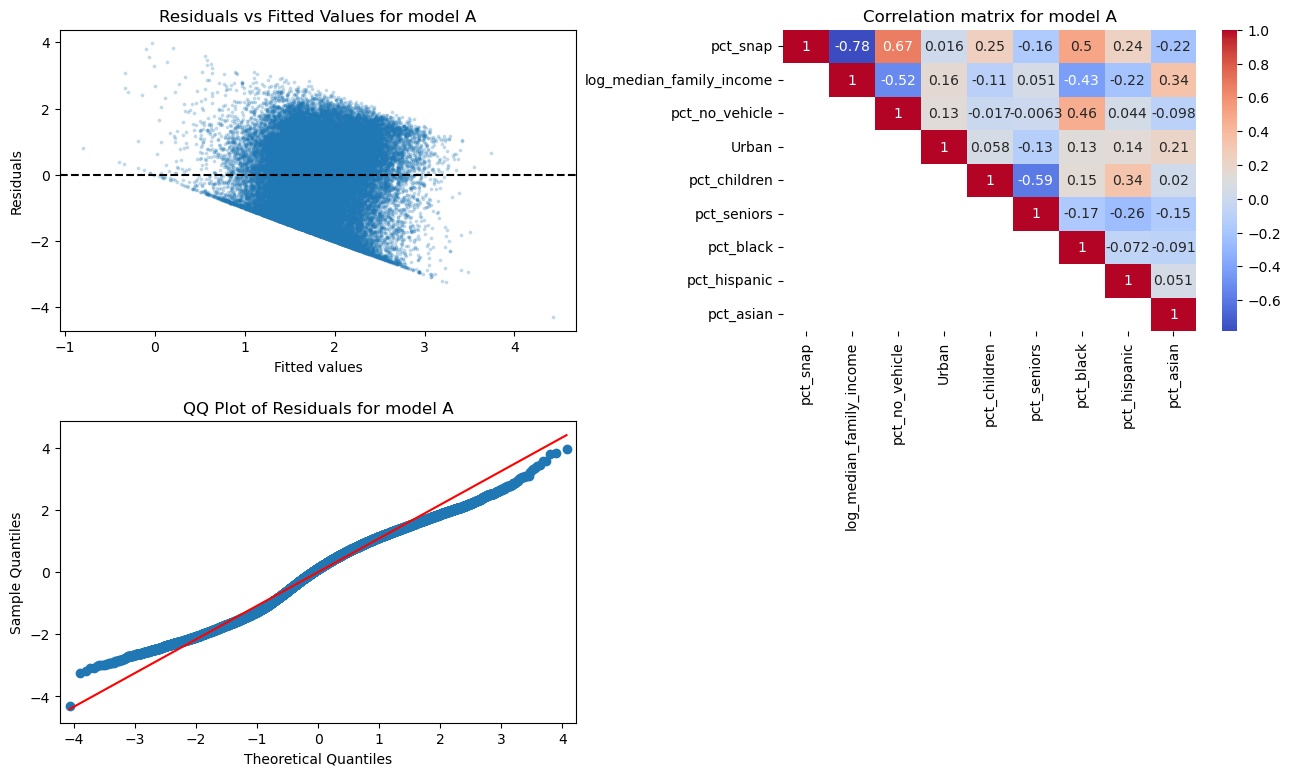

In [41]:
covariates_termA = ['pct_snap','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableA = df_model[covariates_termA].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_A.fittedvalues, model_A.resid, s=3, alpha=0.2)
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model A")
sm.qqplot(model_A.resid, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals for model A")
sns.heatmap(corr_tableA, annot=True, cmap='coolwarm', mask=np.tril(corr_tableA, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model A')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

---
#### Checking all conditions for model B diagnosis 

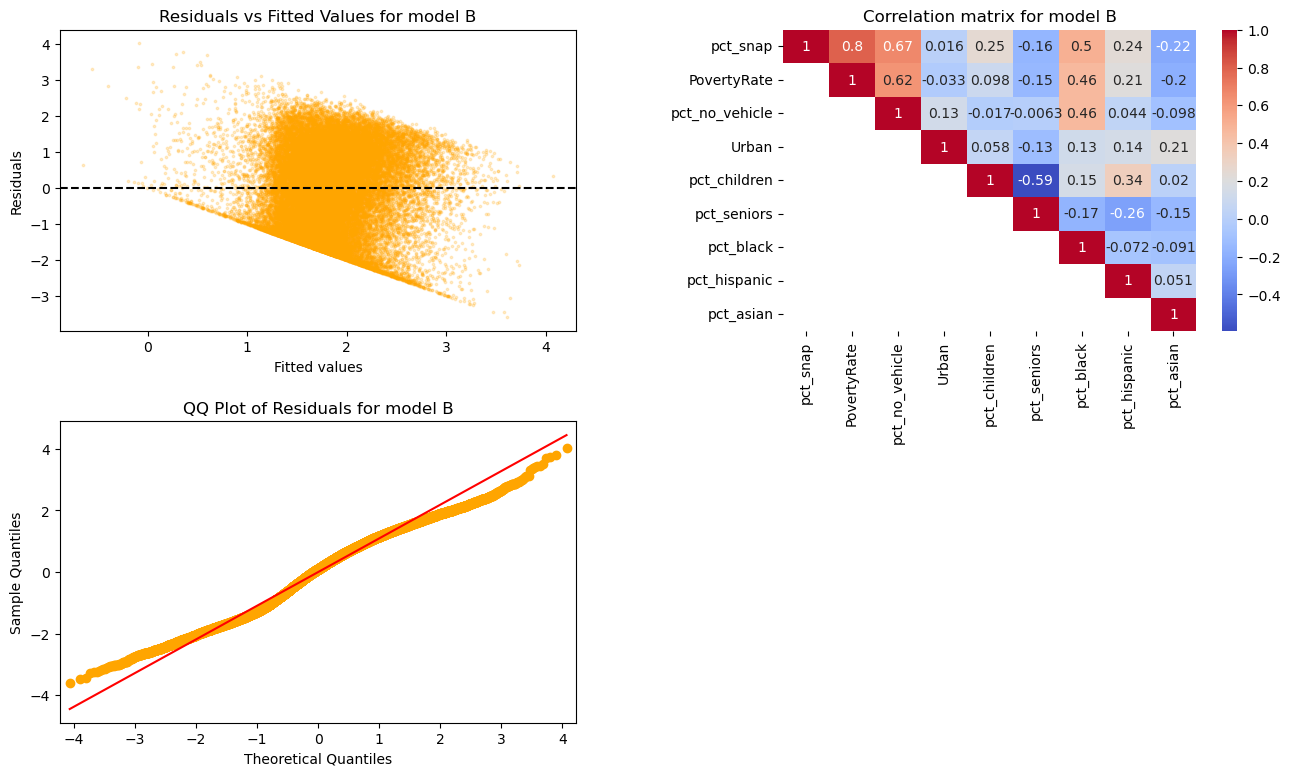

In [43]:
covariates_termB = ['pct_snap','PovertyRate','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableB = df_model[covariates_termB].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_B.fittedvalues, model_B.resid, s=3, alpha=0.2, c='orange')
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model B")
sm.qqplot(model_B.resid, line="s", ax=axes[1, 0],markerfacecolor='orange', markeredgecolor='orange')
axes[1, 0].set_title("QQ Plot of Residuals for model B")
sns.heatmap(corr_tableB, annot=True, cmap='coolwarm', mask=np.tril(corr_tableB, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model B')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

---
#### Checking all conditions for model C diagnosis 

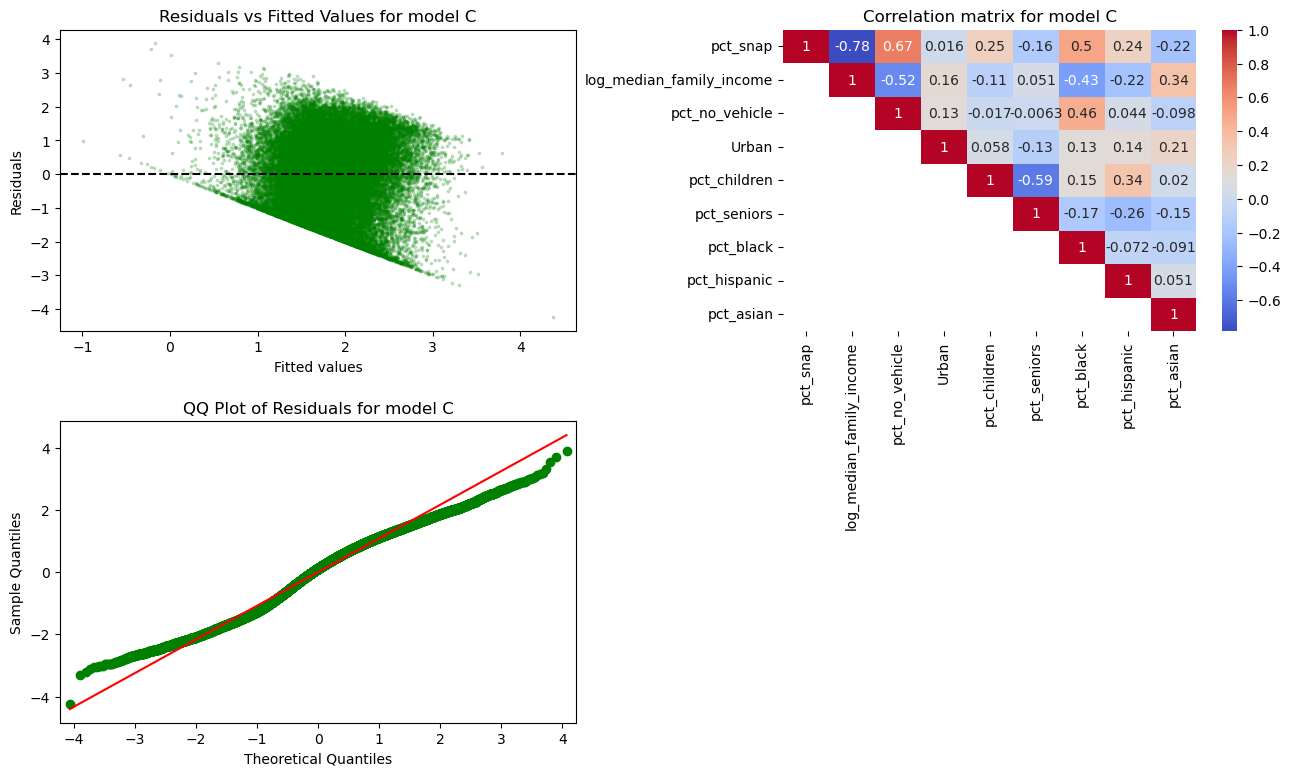

In [44]:
covariates_termC = ['pct_snap','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableC = df_model[covariates_termC].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_C.fittedvalues, model_C.resid, s=3, alpha=0.2, c='green')
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model C")
sm.qqplot(model_C.resid, line="s", ax=axes[1, 0],markerfacecolor='green', markeredgecolor='green')
axes[1, 0].set_title("QQ Plot of Residuals for model C")
sns.heatmap(corr_tableC, annot=True, cmap='coolwarm', mask=np.tril(corr_tableC, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model C')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

|Conditions|Model A analysis|Model B analysis|Model C analysis|
|:--:|:--:|:--:|:--:|
|Independence|$$\checkmark$$|$$\checkmark$$|$$\checkmark$$|
|Identical/homoscedasticity|Heteroscedasticity is noticable on Residual vs Fitted values.|Heteroscedasticity is noticable on Residual vs Fitted values.|Heteroscedasticity is noticable on Residual vs Fitted values.|
|Normality|We aren't able to satisfy the normality due to the heavy tails more noticable on the points below the line.| Similarly, we notice a heavier tail noticeable.|We notice a heavier tail compared to the model A and model B QQ-plots.|
|Linearity|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|
|Multicollinearity| Multicollinearity not pronounced via the VIF values. |Multicollinearity not pronounced via the VIF values. |Some severe level of multicollinearity compared to as Model A and Model B|

* Identical conditions resolved by using the cluster covariance type for standard error.
* Normality is not as great as an issue since we have a data set of 42156 observations.
* Linearity issue reduced by our use of `log(response)`.
* Multicollinearity only presented in Model C but we use interaction term so we expect correlation between the covariates with the interaction term. The other covariates without the interaction term are as expected not as severe in the VIF inflation. 